<a href="https://colab.research.google.com/github/jagan18Jstar/Valuator-Pro/blob/main/ML_Project_Banglore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Environment Initialization & Real Data Loading

In [7]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Set global plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Download latest version of the dataset via kagglehub
path = kagglehub.dataset_download("amitabhajoy/bengaluru-house-price-data")
print("Path to dataset files:", path)

def load_and_clean_real_dataset(dataset_dir):
    """
    Loads the real Bengaluru dataset and resolves messy real-world strings,
    ranges, and high categorical cardinality before sending data to pipeline nodes.
    """
    csv_path = os.path.join(dataset_dir, "Bengaluru_House_Data.csv")
    if not os.path.exists(csv_path):
        csv_files = [f for f in os.listdir(dataset_dir) if f.endswith('.csv')]
        if csv_files:
            csv_path = os.path.join(dataset_dir, csv_files[0])
        else:
            raise FileNotFoundError(f"Missing core raw data CSV in pathway: {dataset_dir}")

    print(f"[*] Extracting production asset matrix: Compiling data from {csv_path}...")
    df_raw = pd.read_csv(csv_path)
    df_cleaned = df_raw.copy()

    # Feature Parser 1: Safely convert 'total_sqft' text/ranges to Float
    def parse_sqft(x):
        if pd.isna(x):
            return np.nan
        x_str = str(x).strip()
        if '-' in x_str:
            parts = x_str.split('-')
            try:
                return (float(parts[0].strip()) + float(parts[1].strip())) / 2.0
            except:
                return np.nan
        try:
            return float(x_str)
        except:
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", x_str)
            return float(nums[0]) if nums else np.nan

    df_cleaned['total_sqft'] = df_cleaned['total_sqft'].apply(parse_sqft)

    # Feature Parser 2: Isolate pure continuous numeric values from 'size'
    def parse_bhk(x):
        if pd.isna(x):
            return np.nan
        try:
            return float(str(x).split()[0])
        except:
            return np.nan

    df_cleaned['bhk'] = df_cleaned['size'].apply(parse_bhk)
    df_cleaned = df_cleaned.rename(columns={'price': 'target_price'})

    # Feature Parser 3: Group rare locations under 'other' to protect downstream memory matrices
    df_cleaned['location'] = df_cleaned['location'].fillna('other').astype(str).str.strip()
    location_counts = df_cleaned['location'].value_counts()
    rare_locations = location_counts[location_counts <= 10].index
    df_cleaned['location'] = df_cleaned['location'].apply(lambda x: 'other' if x in rare_locations else x)

    # Prune unnecessary high-null or high-cardinality features
    features_to_keep = ['total_sqft', 'bhk', 'bath', 'balcony', 'location', 'area_type', 'target_price']
    df_cleaned = df_cleaned[features_to_keep]

    return df_cleaned

# Load the updated clean data frame
df = load_and_clean_real_dataset(path)
print("[+] Production Frame Loaded Successfully.")

Using Colab cache for faster access to the 'bengaluru-house-price-data' dataset.
Path to dataset files: /kaggle/input/bengaluru-house-price-data
[*] Extracting production asset matrix: Compiling data from /kaggle/input/bengaluru-house-price-data/Bengaluru_House_Data.csv...
[+] Production Frame Loaded Successfully.


Cognitive Exploratory Data Analysis (Visualizations)


--- DATASET STRUCTURAL COMPOSITION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   total_sqft    13320 non-null  float64
 1   bhk           13304 non-null  float64
 2   bath          13247 non-null  float64
 3   balcony       12711 non-null  float64
 4   location      13320 non-null  object 
 5   area_type     13320 non-null  object 
 6   target_price  13320 non-null  float64
dtypes: float64(5), object(2)
memory usage: 728.6+ KB

--- DETECTING NULL QUANTITIES ---
total_sqft        0
bhk              16
bath             73
balcony         609
location          0
area_type         0
target_price      0
dtype: int64


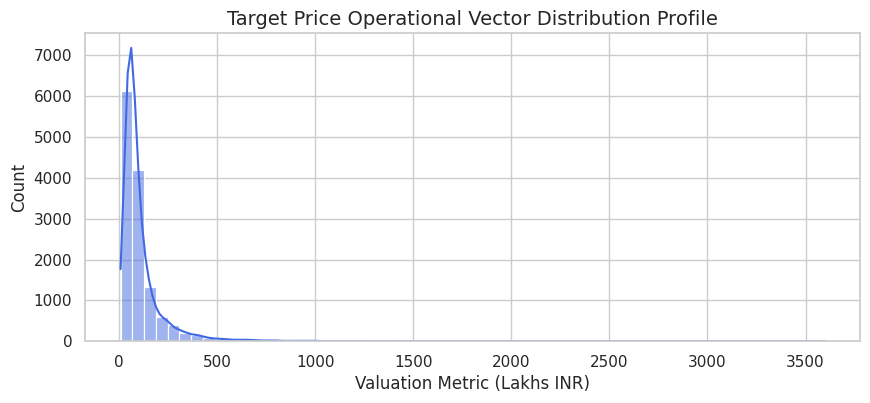

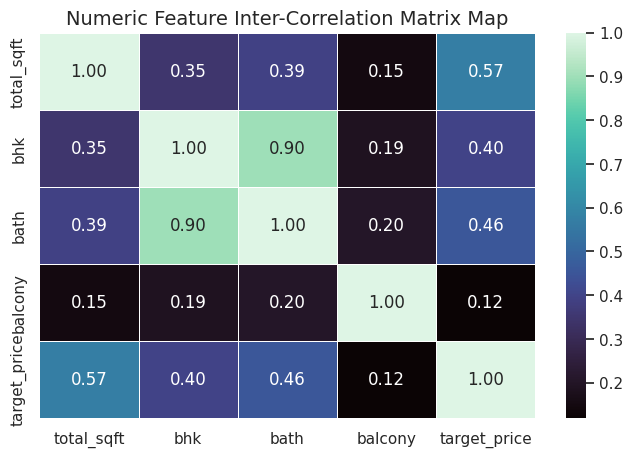

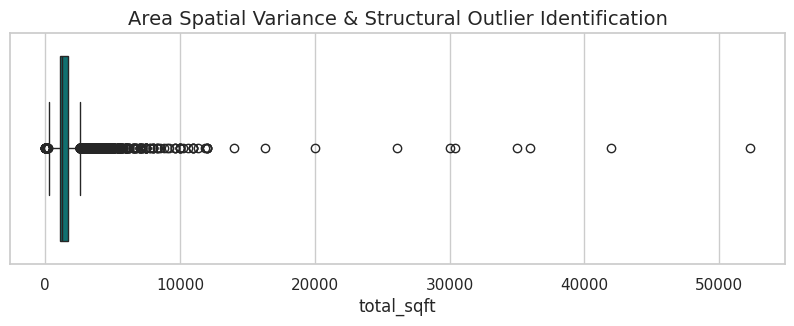

In [8]:
print("\n--- DATASET STRUCTURAL COMPOSITION ---")
df.info()

print("\n--- DETECTING NULL QUANTITIES ---")
print(df.isnull().sum())

# Visualization 1: Operational Distribution Profile of target vector
plt.figure(figsize=(10, 4))
sns.histplot(df['target_price'], kde=True, color='royalblue', bins=60)
plt.title('Target Price Operational Vector Distribution Profile', fontsize=14)
plt.xlabel('Valuation Metric (Lakhs INR)')
plt.show()

# Visualization 2: Feature Matrix Cross-Correlation Tracking (Numeric Only)
plt.figure(figsize=(8, 5))
numeric_matrix = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_matrix.corr(), annot=True, cmap='mako', fmt=".2f", linewidths=0.5)
plt.title('Numeric Feature Inter-Correlation Matrix Map', fontsize=14)
plt.show()

# Visualization 3: Outlier Distribution Boundary Boxplots
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['total_sqft'], color='teal')
plt.title('Area Spatial Variance & Structural Outlier Identification', fontsize=14)
plt.show()

Isolating Pipelines & Data Splits

In [9]:
# Eliminate incomplete records from target vector to preserve training fidelity
df = df.dropna(subset=['target_price'])

X = df.drop(columns=['target_price'])
y = df['target_price']

# Partitioning array sets via standard random distributions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define real data explicit boundaries to safely direct pipeline operations
numeric_features = ['total_sqft', 'bhk', 'bath', 'balcony']
categorical_features = ['location', 'area_type']

# Structural preprocessing components designed to neutralize Data Leakage
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Consolidating execution nodes inside an atomic ColumnTransformer matrix
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("[+] Zero-leakage execution transformers initialized and verified.")

[+] Zero-leakage execution transformers initialized and verified.


Multi-Model Evaluation Matrix

[✔] Evaluation Done for: Linear Regression  -> R2 Score: 0.5609
[✔] Evaluation Done for: Decision Tree      -> R2 Score: 0.5563
[✔] Evaluation Done for: Random Forest      -> R2 Score: 0.6847
[✔] Evaluation Done for: XGBoost            -> R2 Score: 0.6936

--- PERFORMANCE EVALUATION MATRIX ---
                         MAE          MSE       RMSE        R2
Linear Regression  40.655696  9347.664513  96.683321  0.560947
Decision Tree      34.147053  9447.433486  97.197909  0.556261
Random Forest      31.012795  6711.959087  81.926547  0.684745
XGBoost            33.337749  6524.119182  80.772020  0.693567


/tmp/ipykernel_17423/3311157922.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metrics_df['R2'], ax=axes[0], palette='flare')


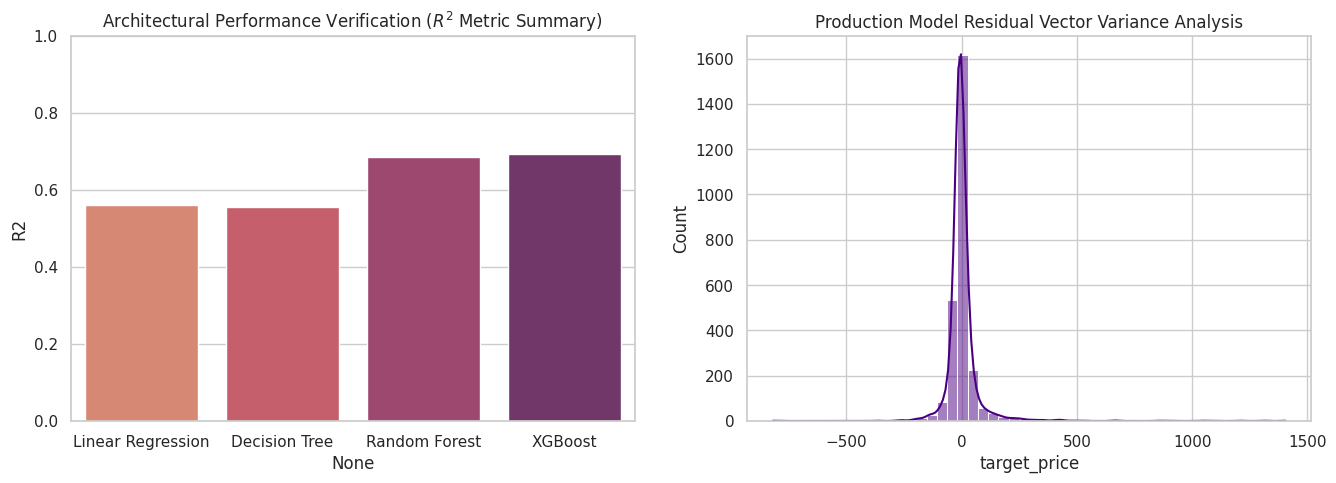

In [4]:
evaluation_vault = {}
trained_pipelines = {}

candidate_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=40, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=50, learning_rate=0.1, max_depth=6)
}

for name, algo in candidate_models.items():
    # Wrap model directly in the transformation sequence layer
    full_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', algo)])

    # Train tracking parameters strictly on real training records
    full_pipeline.fit(X_train, y_train)
    predictions = full_pipeline.predict(X_test)

    # Extract structural metrics
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    evaluation_vault[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
    trained_pipelines[name] = full_pipeline
    print(f"[✔] Evaluation Done for: {name:18s} -> R2 Score: {r2:.4f}")

# Display structured operational metric table
metrics_df = pd.DataFrame(evaluation_vault).T
print("\n--- PERFORMANCE EVALUATION MATRIX ---")
print(metrics_df)

# Visualizing Algorithm Performance Metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=metrics_df.index, y=metrics_df['R2'], ax=axes[0], palette='flare')
axes[0].set_title('Architectural Performance Verification ($R^2$ Metric Summary)')
axes[0].set_ylim(0, 1)

# Plotting Error Distribution Matrix from elite predictor (XGBoost)
best_preds = trained_pipelines['XGBoost'].predict(X_test)
residuals = y_test - best_preds
sns.histplot(residuals, kde=True, ax=axes[1], color='indigo', bins=50)
axes[1].set_title('Production Model Residual Vector Variance Analysis')
plt.show()

Hyperparameter Tuning & Asset Serialization

In [5]:
print("[*] Initiating Grid Optimization Framework across core XGBoost parameters...")

tuning_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('xgb', XGBRegressor(random_state=42))])

# Setting optimization boundaries compatible with mapped datasets
param_grid = {
    'xgb__n_estimators': [50, 100],
    'xgb__max_depth': [5, 7],
    'xgb__learning_rate': [0.1]
}

grid_matrix_search = GridSearchCV(tuning_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_matrix_search.fit(X_train, y_train)

print(f"[+] Optimal Parameter Matrix Discovered: {grid_matrix_search.best_params_}")
production_ready_model = grid_matrix_search.best_estimator_

# Serializing model framework directly to persistent storage disk
model_asset_path = 'production_avm_model.pkl'
joblib.dump(production_ready_model, model_asset_path)
print(f"[+] Model pipeline binary packed and stored successfully at: '{model_asset_path}'")

[*] Initiating Grid Optimization Framework across core XGBoost parameters...
[+] Optimal Parameter Matrix Discovered: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 100}
[+] Model pipeline binary packed and stored successfully at: 'production_avm_model.pkl'


Interactive UI Production Simulator

In [6]:
#@title 🏡 Real Bengaluru Property Valuation Simulator Panel { run: "auto" }

# Updated form configurations aligned with authentic dataset parameters
location = "Electronic City" #@param ["Whitefield", "Sarjapur Road", "Electronic City", "Kanakpura Road", "Thanisandra", "Yelahanka", "other"] {allow-input: true}
area_type = "Super built-up Area" #@param ["Super built-up Area", "Built-up Area", "Plot Area", "Carpet Area"]
total_sqft = 3400 #@param {type:"slider", min:300, max:10000, step:50}
bhk = 2 #@param [1, 2, 3, 4, 5, 6, 7, 8] {type:"raw"}
bath = 2 #@param [1, 2, 3, 4, 5, 6, 7, 8] {type:"raw"}
balcony = 1 #@param [0, 1, 2, 3] {type:"raw"}

def query_valuation_engine(total_sqft, bhk, bath, balcony, location, area_type):
    """
    Accepts raw real estate entries directly from the user interface panel,
    constructs an operational runtime payload frame, and executes the serialized pipeline.
    """
    import os
    import joblib
    import pandas as pd

    if not os.path.exists('production_avm_model.pkl'):
        raise FileNotFoundError("Target model engine asset binary missing. Please compile the tuning stages above first.")

    loaded_engine = joblib.load('production_avm_model.pkl')

    # Reconstitute raw metrics into standard transactional feature structures
    user_payload = pd.DataFrame([{
        'total_sqft': float(total_sqft),
        'bhk': float(bhk),
        'bath': float(bath),
        'balcony': float(balcony),
        'location': str(location).strip(),
        'area_type': str(area_type)
    }])

    valuation_prediction = loaded_engine.predict(user_payload)[0]

    print(f"\n--- VALUATION ENGINE REPORT ---")
    print(f"Location Target Area: {location} ({area_type})")
    print(f"Dimensional Metrics  : {total_sqft} SqFt | {int(bhk)} BHK")
    print(f"Structural Layout    : {int(bath)} Bathrooms | {int(balcony)} Balconies")
    print(f"==========================================")
    print(f"ESTIMATED VALUE      : Lakhs INR {valuation_prediction:,.2f}")
    print(f"==========================================")

# Trigger evaluation whenever user updates slider arguments
query_valuation_engine(
    total_sqft=total_sqft,
    bhk=bhk,
    bath=bath,
    balcony=balcony,
    location=location,
    area_type=area_type
)


--- VALUATION ENGINE REPORT ---
Location Target Area: Electronic City (Super built-up Area)
Dimensional Metrics  : 3400 SqFt | 2 BHK
Structural Layout    : 2 Bathrooms | 1 Balconies
ESTIMATED VALUE      : Lakhs INR 253.88
